## Microproyecto 2

Instalar las librerias necesarias

In [21]:
# Instalación de librerías
%pip install nltk
%pip install openpyxl
%pip install wordcloud

# Librerías generales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# NLTK
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

from nltk.tokenize import word_tokenize
from nltk import RegexpTokenizer
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer 
from nltk.stem.snowball import SnowballStemmer ## para espa;ol.


# Procesamiento de texto
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD


# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.metrics import confusion_matrix


# Excel
import openpyxl

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\jsroj\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\jsroj\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jsroj\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Llamar los datos / Revisar si hay duplicados o faltantes

In [2]:
data = pd.read_excel('datos_microproy_2.xlsx')
data

,textos,ODS
0,"""Aprendizaje"" y ""educación"" se consideran sinó...",4
1,No dejar clara la naturaleza de estos riesgos ...,6
2,"Como resultado, un mayor y mejorado acceso al ...",13
3,Con el Congreso firmemente en control de la ju...,16
4,"Luego, dos secciones finales analizan las impl...",5
...,...,...
9651,Esto implica que el tiempo de las mujeres en e...,5
9652,"Sin embargo, estas fallas del mercado implican...",3
9653,El hecho de hacerlo y cómo hacerlo dependerá e...,9
9654,"Esto se destacó en el primer estudio de caso, ...",6


In [3]:
## Duplicados o faltantes 
print(data.isna().sum())
print(data.duplicated().sum())

textos    0
ODS       0
dtype: int64
0


Dividir en variables explicativas X y objetivo y

In [4]:
X= data['textos']
y= data['ODS']

In [5]:
print(data["ODS"].unique())

[ 4  6 13 16  5  2  3 11  8  1  7 15  9 14 10 12]


## 1. Preparación de los textos utilizando el esquema de bolsa de palabras (BOW)l con una pesado TF-IDF. Para este paso construir un pipeline que integre las transformaciones que se consideren adecuadas.

Crear la funcion de preprocesamiento que incluye:

1. Tokenizacion
2. Eliminar puntuacion
3. Eliminar stopwords
4. Steamming

Luego, en el pipeline, se aplica BOW + TF-IDF.

La tokenización se hace con `RegexpTokenizer(r'\w+')`, que solo conserva secuencias de letras y números, por lo que la puntuación se elimina en el mismo paso.

Para que el preprocesamiento sea eficiente, las stopwords en español se cargan una sola vez y se guardan en un `set` (`STOPWORDS_ES`), lo que hace que la búsqueda de cada palabra sea casi instantánea. El tokenizer y el stemmer también se crean una sola vez, fuera de la función, en lugar de crearse en cada llamada.

Se eligio para el proceso de steamming, SnowballStemmer, ya que cuenta con un algoritmo específico para el procesamiento de palabras en español.

In [6]:
tokenizer = RegexpTokenizer(r'\w+')
STOPWORDS_ES = set(stopwords.words('spanish'))   # set: búsqueda casi instantánea
stemmer = SnowballStemmer("spanish")

def text_preprocess(text): 
    tokens = tokenizer.tokenize(text)
    tokens = [word for word in tokens if word not in STOPWORDS_ES]
    tokens = [stemmer.stem(word) for word in tokens]
    return ' '.join(tokens)

In [7]:
preprocess = FunctionTransformer(
    lambda x: x.apply(text_preprocess)
)

Se utilizó una representación tipo Bag of Words (BOW), en la cual cada documento se representa mediante un conjunto de términos, asignando a cada término un peso calculado mediante TF-IDF.

In [8]:
pipeline = Pipeline([
    ('preprocess', preprocess),
    ('tfidf', TfidfVectorizer())
])

Tiene sentido hacerlo primero sobre X porque por ahora es solo un ejercicio no supervisado

In [9]:
X_tfidf = pipeline.fit_transform(X)

In [10]:
print(X_tfidf.shape)

(9656, 18465)


## 2. A partir de la matriz TF-IDF construida en el paso anterior, aplica el algoritmo SVD truncado (TruncatedSVD de scikit-learn) para obtener un modelo de tópicos mediante análisis semántico latente (LSA). Explora un número reducido de componentes (por ejemplo, entre 10 y 20) y, para al menos 5 de ellas, identifica y muestra las palabras con mayor peso (loadings), a modo de "tópicos". Interpreta cualitativamente si estos tópicos guardan relación con algunos de los 17 ODS trabajados en el proyecto.

Para aplicar LSA se usa `TruncatedSVD` sobre la matriz TF-IDF. Este algoritmo reduce la matriz a un número pequeño de componentes, donde cada componente agrupa palabras que suelen aparecer juntas en los documentos. Se usa la versión truncada porque trabaja directamente con matrices dispersas, como la que genera TF-IDF.

Para elegir el número de componentes se comparan 10, 11, 12, 13, 15 y 20, midiendo la varianza explicada acumulada de cada opción.

In [11]:
for n in [10, 11, 12, 13, 15, 20]:
    svd = TruncatedSVD(n_components=n, random_state=32)
    svd.fit(X_tfidf)
    print(f"{n} componentes -> varianza explicada: {svd.explained_variance_ratio_.sum():.4f}")

10 componentes -> varianza explicada: 0.0494
11 componentes -> varianza explicada: 0.0526
12 componentes -> varianza explicada: 0.0556
13 componentes -> varianza explicada: 0.0585
15 componentes -> varianza explicada: 0.0639
20 componentes -> varianza explicada: 0.0758


In [12]:
for n in [10, 11, 12, 13, 15, 20]:
    
    # Crear y ajustar un nuevo SVD
    tsvd = TruncatedSVD(
        n_components=n,
        random_state=32
    )
    
    X_lsa = tsvd.fit_transform(X_tfidf)
    
    # Obtener vocabulario
    vocab = pipeline.named_steps["tfidf"].get_feature_names_out()
    
    # Número de palabras principales
    n_top = 15
    
    print(f"\n{'='*80}")
    print(f"SVD con {n} componentes")
    print(f"{'='*80}")
    
    # Mostrar palabras positivas y negativas de cada componente
    for i, comp in enumerate(tsvd.components_):
        
        # 15 palabras con mayor peso
        topicos_positivos = np.argsort(comp)[::-1][:n_top]
        
        # 15 palabras con menor peso
        topicos_negativos = np.argsort(comp)[:n_top]
        
        print(f"\nTópico {i}")
        print("  (+):", ", ".join(vocab[topicos_positivos]))
        print("  (-):", ", ".join(vocab[topicos_negativos]))


SVD con 10 componentes

Tópico 0
  (+): pais, polit, pued, desarroll, mujer, agu, la, trabaj, educ, gener, el, en, derech, mejor, mayor
  (-): olmo, cedr, silvestris, 1093, 9780198797968, methods, users, improv, 5923, 4448, helping, decomposition, 1608, parent, nicol

Tópico 1
  (+): agu, energ, cost, energet, electr, renov, gestion, climat, eficient, inversion, suministr, recurs, tecnolog, desarroll, uso
  (-): derech, mujer, trabaj, human, hombr, internacional, educ, niñ, gener, iguald, laboral, emple, articul, social, violenci

Tópico 2
  (+): derech, internacional, human, agu, articul, polit, tribunal, ley, penal, nacional, este, trat, justici, gestion, legal
  (-): ingres, pobrez, trabaj, mujer, educ, emple, tas, pais, laboral, hombr, niñ, mayor, ocde, aument, años

Tópico 3
  (+): mujer, agu, gener, pobrez, derech, hombr, ingres, energ, trabaj, emple, aument, econom, iguald, electr, desiguald
  (-): educ, escuel, estudi, docent, evalu, aprendizaj, atencion, salud, profesional, p

Interpreta cualitativamente si estos tópicos guardan relación con algunos de los 17 ODS trabajados en el proyecto.

<table>
<colgroup>
    <col style="width: 10%;">
    <col style="width: 45%;">
    <col style="width: 45%;">
</colgroup>

<tr>
    <th>Tópico</th>
    <th>Palabras principales</th>
    <th>ODS relacionados</th>
</tr>

<tr>
    <td><b>Tópico 0 (+)</b></td>
    <td>pais, polit, pued, desarroll, mujer, agu, la, trabaj, educ, gener, el, en, derech, mejor, mayor, deb, aument, nivel, econom, los</td>
    <td><b>ODS 5:</b> Igualdad de género<br><b>ODS 10:</b> Reducción de las desigualdades<br><b>ODS 16:</b> Paz, justicia e instituciones sólidas</td>
</tr>

<tr>
    <td><b>Tópico 1 (+)</b></td>
    <td>agu, energ, cost, energet, electr, renov, gestion, climat, eficient, inversion, suministr, recurs, tecnolog, desarroll, uso, financi, infraestructur, preci, produccion, hidric</td>
    <td><b>ODS 7:</b> Energía asequible y no contaminante<br><b>ODS 13:</b> Acción por el clima</td>
</tr>

<tr>
    <td><b>Tópico 2 (+)</b></td>
    <td>derech, internacional, human, agu, articul, polit, tribunal, ley, penal, nacional, este, trat, justici, gestion, legal, constitucional, estad, desarroll, jurid, aplic</td>
    <td><b>ODS 16:</b> Paz, justicia e instituciones sólidas<br><b>ODS 17:</b> Alianzas para lograr los objetivos</td>
</tr>

<tr>
    <td><b>Tópico 3 (+)</b></td>
    <td>mujer, agu, gener, pobrez, derech, hombr, ingres, energ, trabaj, emple, aument, econom, iguald, desiguald, electr, produccion, tas, hogar, remuner, crecimient</td>
    <td><b>ODS 5:</b> Igualdad de género<br><b>ODS 8:</b> Trabajo decente y crecimiento económico<br><b>ODS 10:</b> Reducción de las desigualdades<br><b>ODS 12:</b> Producción y consumo responsables</td>
</tr>

<tr>
    <td><b>Tópico 4 (+)</b></td>
    <td>agu, educ, salud, escuel, calid, atencion, hidric, niñ, residual, subterran, mujer, servici, cuenc, estudi, potabl, mental, trabaj, gestion, tratamient, rieg</td>
    <td><b>ODS 6:</b> Agua limpia y saneamiento</td>
</tr>

<tr>
    <td><b>Tópico 5 (+)</b></td>
    <td>mujer, gener, hombr, iguald, agu, polit, particip, educ, energ, trabaj, desarroll, empres, escuel, violenci, sector, apoy, remuner, recurs, gestion, muj</td>
    <td><b>ODS 1:</b> Fin de la pobreza<br><b>ODS 5:</b> Igualdad de género<br><b>ODS 10:</b> Reducción de las desigualdades</td>
</tr>

<tr>
    <td><b>Tópico 6 (+)</b></td>
    <td>salud, atencion, servici, mental, medic, pacient, mujer, primari, sanitari, segur, public, hospital, enfermedad, calid, tratamient, acces, hospitalari, gast, proveedor, trastorn</td>
    <td><b>ODS 3:</b> Salud y bienestar</td>
</tr>

<tr>
    <td><b>Tópico 7 (+)</b></td>
    <td>energ, derech, electr, educ, renov, escuel, energet, cost, estudi, sistem, human, atencion, eficient, salud, preci, docent, primari, eolic, años, servici</td>
    <td><b>ODS 7:</b> Energía asequible y no contaminante</td>
</tr>

<tr>
    <td><b>Tópico 8 (+)</b></td>
    <td>trabaj, emple, laboral, empres, merc, product, sector, salari, desemple, tiemp, remuner, innov, econom, habil, agricol, crecimient, contrat, aument, informal, segur</td>
    <td><b>ODS 8:</b> Trabajo decente y crecimiento económico<br><b>ODS 12:</b> Producción y consumo responsables</td>
</tr>

<tr>
    <td><b>Tópico 9 (+)</b></td>
    <td>climat, pais, financi, ocde, millon, mujer, inform, años, adapt, cambi, promedi, clim, derech, hombr, internacional, proporcion, usd, 000, en, año</td>
    <td><b>ODS 1:</b> Fin de la pobreza<br><b>ODS 13:</b> Acción por el clima<br><b>ODS 17:</b> Alianzas para lograr los objetivos</td>
</tr>

<tr>
    <td><b>Tópico 10 (+)</b></td>
    <td>climat, evalu, pued, cambi, trabaj, docent, cost, adapt, energ, riesg, gener, inform, tiemp, indic, efect, result, pobrez, diferent, ser, ingres</td>
    <td><b>ODS 13:</b> Acción por el clima</td>
</tr>

<tr>
    <td><b>Tópico 11 (+)</b></td>
    <td>pobrez, niñ, mujer, desarroll, financi, energ, program, trabaj, pobr, infantil, famili, servici, urban, rural, empres, proyect, viv, energet, climat, privacion</td>
    <td><b>ODS 1:</b> Fin de la pobreza<br><b>ODS 9:</b> Industria, innovación e infraestructura</td>
</tr>

<tr>
    <td><b>Tópico 12 (+)</b></td>
    <td>aliment, produccion, mujer, product, pued, pesc, escuel, alimentari, agricol, preci, niñ, tierr, aument, estudi, deb, import, valor, pesquer, recurs, residu</td>
    <td><b>ODS 2:</b> Hambre cero</td>
</tr>

<tr>
    <td><b>Tópico 13 (+)</b></td>
    <td>educ, climat, cambi, niñ, financi, adapt, aument, inversion, social, riesg, pued, agu, derech, superior, salud, polit, crecimient, sector, terciari, merc</td>
    <td><b>ODS 1:</b> Fin de la pobreza<br><b>ODS 13:</b> Acción por el clima</td>
</tr>

<tr>
    <td><b>Tópico 14 (+)</b></td>
    <td>trabaj, salud, niñ, energ, gener, emple, pesc, polit, educ, pobrez, mental, objet, energet, produccion, aliment, alimentari, sosten, poblacion, mundial, iguald</td>
    <td><b>ODS 1:</b> Fin de la pobreza<br><b>ODS 8:</b> Trabajo decente y crecimiento económico</td>
</tr>

<tr>
    <td><b>Tópico 15 (+)</b></td>
    <td>gener, educ, iguald, residu, financi, dat, cost, niñ, inform, servici, public, electr, gestion, estadist, bosqu, empres, forestal, desech, trabaj, millon</td>
    <td><b>ODS 15:</b> Vida de ecosistemas terrestres</td>
</tr>

<tr>
    <td><b>Tópico 16 (+)</b></td>
    <td>urban, niñ, transport, ciudad, are, planif, pued, zon, años, polit, rural, nivel, local, nacional, tiemp, suel, cambi, trabaj, ciud, plan</td>
    <td><b>ODS 9:</b> Industria, innovación e infraestructura<br><b>ODS 11:</b> Ciudades y comunidades sostenibles</td>
</tr>

<tr>
    <td><b>Tópico 17 (+)</b></td>
    <td>desarroll, pais, gener, urban, derech, econom, ocde, human, acces, crecimient, mejor, pued, calid, rural, infraestructur, niñ, indic, aliment, evalu, iguald</td>
    <td><b>ODS 9:</b> Industria, innovación e infraestructura<br><b>ODS 8:</b> Trabajo decente y crecimiento económico<br><b>ODS 16:</b> Paz, justicia e instituciones sólidas</td>
</tr>

<tr>
    <td><b>Tópico 18 (+)</b></td>
    <td>ingres, gener, docent, escuel, iguald, program, desiguald, bosqu, forestal, salud, urban, derech, desarroll, plan, rural, cambi, gast, aument, tierr</td>
    <td><b>ODS 4:</b> Educación de calidad<br><b>ODS 15:</b> Vida de ecosistemas terrestres</td>
</tr>

<tr>
    <td><b>Tópico 19 (+)</b></td>
    <td>niñ, aliment, escuel, polit, pais, financi, alimentari, public, preci, social, gast, segur, gener, import, gobiern, trabaj, agricol, produccion, padr, insegur</td>
    <td><b>ODS 4:</b> Educación de calidad<br><b>ODS 2:</b> Hambre cero</td>
</tr>

</table>

No hay términos claramente asociados con ODS 14, Vida submarina como océanos, mares, ecosistemas marinos, pesca, contaminación marina, etc.

## 3. Desarrollo de un modelo de clasificación que permita relacionar un texto con un ODS. Para manejar la complejidad del espacio de entrada, puedes reutilizar la misma descomposición SVD obtenida en la actividad anterior (LSA), o aplicar otro algoritmo de reducción de la dimensionalidad que consideres pertinente

Se decidió utilizar TruncatedSVD para reducir la dimensionalidad de la matriz TF-IDF, debido a que es una técnica ampliamente utilizada en procesamiento de textos y permite trabajar eficientemente con matrices dispersas de alta dimensionalidad. Además, su aplicación sobre la matriz TF-IDF permite obtener una representación LSA en un espacio de menor dimensión, donde los componentes pueden interpretarse como estructuras o temas latentes presentes en los documentos.

Dividir el set de datos en train y test.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
X_train_tfidf = pipeline.fit_transform(X_train) ## Preprocesamiento + TF-IDF
X_train_lsa = tsvd.fit_transform(X_train_tfidf) ## Reducción de dimensionalidad + espacio semántico latente

Se decidió utilizar Support Vector Machine (SVM) debido a que es un algoritmo ampliamente utilizado en problemas de clasificación y resulta adecuado para trabajar con espacios de características de alta dimensionalidad. En este proyecto, los textos fueron representados inicialmente mediante TF-IDF, generando un espacio de 18.465 características, y posteriormente se aplicó TruncatedSVD para obtener una representación de menor dimensión. Además, SVM permite utilizar diferentes funciones kernel, lo que posibilita evaluar relaciones lineales y no lineales entre los textos y las categorías de ODS.

Se utilizó GridSearchCV para evaluar diferentes combinaciones de hiperparámetros del modelo SVM. Para cada combinación, GridSearchCV realizó una validación cruzada sobre el conjunto de entrenamiento y calculó el desempeño del modelo. Finalmente, se seleccionó la combinación de hiperparámetros que obtuvo el mejor desempeño promedio durante la validación cruzada. El conjunto de prueba se mantuvo separado y se utilizó posteriormente para realizar la evaluación final del modelo seleccionado.

In [15]:
param_grid = [
    {
        "kernel": ["linear"],
        "C": [0.01, 0.1, 1, 10, 100]
    },
    {
        "kernel": ["rbf"],
        "C": [0.01, 0.1, 1, 10, 100],
        "gamma": ["scale", 0.001, 0.01, 0.1, 1]
    },
    {
        "kernel": ["poly"],
        "C": [0.01, 0.1, 1, 10, 100],
        "gamma": ["scale", 0.001, 0.01, 0.1],
        "degree": [2, 3, 4]
    },
    {
        "kernel": ["sigmoid"],
        "C": [0.01, 0.1, 1, 10, 100],
        "gamma": ["scale", 0.001, 0.01, 0.1]
    }
]

grid = GridSearchCV(
    estimator=SVC(random_state=32),
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

grid.fit(X_train_lsa, y_train)

print("Mejores parámetros:")
print(grid.best_params_)

print("\nMejor F1 macro:")
print(grid.best_score_)

Mejores parámetros:
{'C': 100, 'gamma': 1, 'kernel': 'rbf'}

Mejor F1 macro:
0.7599040115835336


In [16]:
## Predicción

X_test_tfidf = pipeline.transform(X_test)       ## Preprocesamiento + TF-IDF
X_test_lsa = tsvd.transform(X_test_tfidf)       ## Reducción de dimensionalidad + espacio semántico latente

In [17]:
modelo_svm = grid.best_estimator_
y_pred = modelo_svm.predict(X_test_lsa)         ## Predicción del ODS

## 4. Evaluación del modelo de clasificación con textos que no hayan sido utilizados para el aprendizaje.

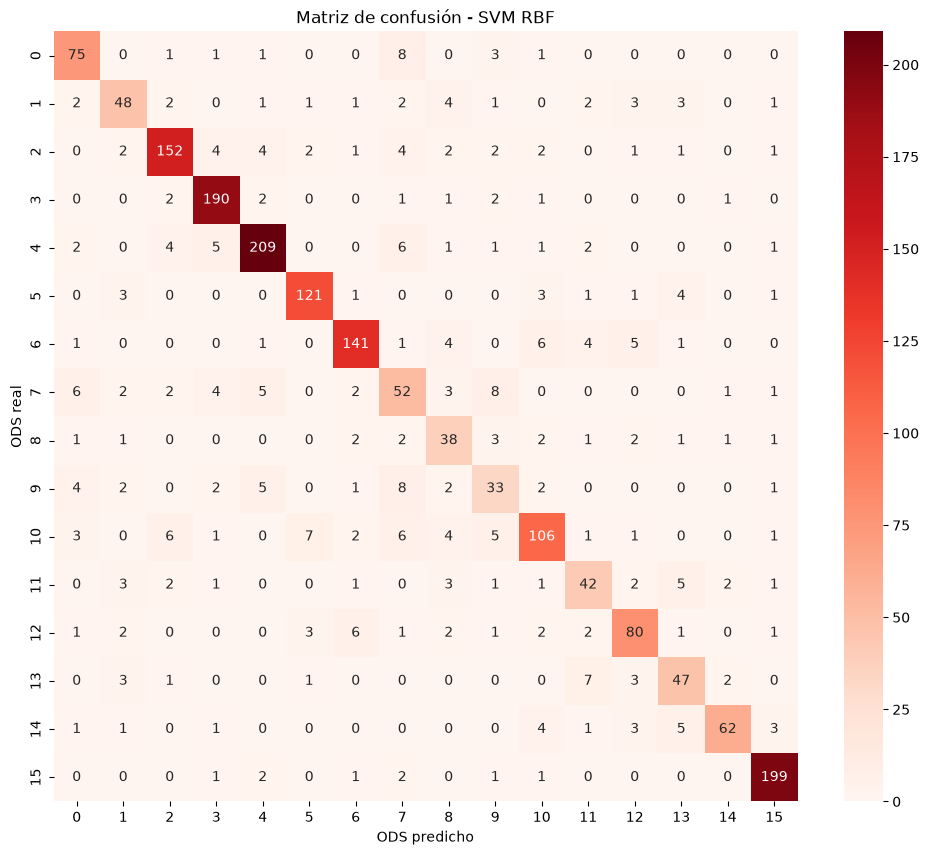

In [22]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds"
)

plt.xlabel("ODS predicho")
plt.ylabel("ODS real")
plt.title("Matriz de confusión - SVM RBF")
plt.show()


In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision
precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

# Recall
recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

# F1
f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1:        {f1:.4f}")

print("\nReporte de clasificación:")
print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

Accuracy:  0.8256
Precision: 0.8279
Recall:    0.8256
F1:        0.8261

Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.78      0.83      0.81        90
           2       0.72      0.68      0.70        71
           3       0.88      0.85      0.87       178
           4       0.90      0.95      0.93       200
           5       0.91      0.90      0.90       232
           6       0.90      0.90      0.90       135
           7       0.89      0.86      0.87       164
           8       0.56      0.60      0.58        86
           9       0.59      0.69      0.64        55
          10       0.54      0.55      0.55        60
          11       0.80      0.74      0.77       143
          12       0.67      0.66      0.66        64
          13       0.79      0.78      0.79       102
          14       0.69      0.73      0.71        64
          15       0.90      0.77      0.83        81
          16       0.94      0.96   

## Conclusiones

### ODS 10 y ODS 8: Reducción de las desigualdades / Trabajo decente y crecimiento económico

ODS 10 (Reducción de las desigualdades) presenta un F1 de 0.55, mientras que el ODS 8 (Trabajo decente y crecimiento económico) tiene un F1 de 0.58, siendo las metricas mas bajas; indicando una mayor dificultad del modelo para identificar correctamente estas clases. Estos dos temas están claramente relacionados y pueden compartir muchos términos y conceptos, especialmente aquellos asociados con empleo, ingresos, oportunidades económicas e inclusión. Por esta razón, no resulta sorprendente que el modelo presente confusiones entre ambas categorías.

### ODS 12 y ODS 14: Producción y consumo responsables / Vida submarina

La relación entre estos dos temas no es tan evidente. En el conjunto de entrenamiento se tienen 313 ejemplos de ODS 14 y 248 ejemplos de ODS 12, siendo ODS 12 una de las clases con menor cantidad de ejemplos. Esto podría dificultar que el modelo aprenda adecuadamente las características que permiten diferenciar esta categoría de las demás. En el conjunto de prueba, ODS 12 presenta un F1 de 0.66, mientras que ODS 14 alcanza un F1 de 0.71.

### ODS 5 y ODS 8: Igualdad de género / Trabajo decente y crecimiento económico

Existe una relación evidente entre ambos temas, especialmente en aspectos como la igualdad de oportunidades laborales, la participación económica y las condiciones de trabajo. Además, conceptos relacionados con igualdad, inclusión y oportunidades pueden aparecer simultáneamente en textos asociados con el trabajo y la economía. ODS 5 presenta un F1 de 0.90, mientras que ODS 8 presenta un F1 de 0.58, por lo que la confusión parece afectar especialmente a la identificación de ODS 8.

### ODS 7 y ODS 13: Energía asequible y no contaminante / Acción por el clima

Estos objetivos también presentan una relación temática importante, especialmente en temas como energías renovables, reducción de emisiones, transición energética y combustibles fósiles. Por esta razón, es posible que determinados textos contengan términos asociados simultáneamente con ambos objetivos. En las métricas, ODS 7 presenta un F1 de 0.87, mientras que ODS 13 presenta un F1 de 0.79.

### ODS 16: Paz, justicia e instituciones sólidas

Un resultado particularmente interesante corresponde al ODS 16 (Paz, justicia e instituciones sólidas), que presenta el mejor desempeño del modelo, con un F1 de 0.95, precision de 0.94 y recall de 0.96. Este resultado resulta llamativo debido al carácter transversal que conceptualmente pueden tener la paz, la justicia y las instituciones en el cumplimiento de los demás ODS. Sin embargo, desde la perspectiva de la clasificación textual, el modelo puede diferenciar bien los textos asociados con este ODS porque contienen términos más específicos relacionados con justicia, instituciones, gobernanza, seguridad, participación, derechos y Estado de derecho, que no son comunes a los otros objetivos.